In [1]:
# ============================================================================
# RQ2: Trust Dynamics in Human-AI Collaboration
# ============================================================================
# What do AI coding agent contribution patterns reveal about trust dynamics
# and cognitive mechanisms in human-AI collaboration?
#
# Compares human reviews on AI-authored PRs vs. human reviews on human-authored
# PRs FROM THE SAME REPOSITORIES, broken down by agent. Metrics: review count
# per PR, review state distributions, review body length, empty-body approval
# rate, author_association distribution.
# ============================================================================

# RQ2: Review Trust Analysis
Comparing how humans review AI-authored PRs vs. human-authored PRs, controlling for repo-level review culture by filtering to overlapping repos.

In [2]:
# %% Cell 1 - Setup and Imports

from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

sys.path.append(str(Path.cwd()))

from analysis_helper import (
    load_local_data,
    load_prs,
    get_agents,
    validate_data,
    normalize_agent_name,
    get_agent_color,
    mannUandCliffdelta,
    FIG_DIR,
    COLOR_MAP,
)

# Matplotlib settings
FONT_SCALE = 1.4
_BASE_FONT = 10

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=FONT_SCALE)

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": _BASE_FONT * FONT_SCALE,
        "axes.titlesize": _BASE_FONT * FONT_SCALE * 1.2,
        "axes.labelsize": _BASE_FONT * FONT_SCALE,
        "xtick.labelsize": _BASE_FONT * FONT_SCALE * 0.9,
        "ytick.labelsize": _BASE_FONT * FONT_SCALE * 0.9,
        "legend.fontsize": _BASE_FONT * FONT_SCALE * 0.9,
    }
)

print("✓ Imports complete")

✓ Imports complete


In [3]:
# %% Cell 2 - Load Data
# ---------------------------------------------------------------------------
# Load all review files + PR metadata (needed for repo-overlap filtering)
# ---------------------------------------------------------------------------

from scripts.utils.config import (
    AI_PR_DIR,
    HUMAN_PR_DIR,
    HUMAN_REVIEW_DIR,
    RAW_DIR,
    AGENTS,
    PROJECT_ROOT,
)

SKIP_AGENTS = {"codegen"}  # Too few reviews for analysis


def load_jsonl(path: Path) -> pd.DataFrame:
    """Load a JSONL file into a DataFrame."""
    if not path.exists():
        print(f"  WARNING: {path.relative_to(PROJECT_ROOT)} not found")
        return pd.DataFrame()
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records)


def load_reviews_jsonl(path: Path) -> pd.DataFrame:
    """Load a JSONL review file into a DataFrame."""
    df = load_jsonl(path)
    if df.empty:
        return df
    if "submitted_at" in df.columns:
        df["submitted_at"] = pd.to_datetime(
            df["submitted_at"], utc=True, errors="coerce"
        )
    if "id" in df.columns:
        df["id"] = df["id"].astype(str)
    if "pr_id" in df.columns:
        df["pr_id"] = df["pr_id"].astype(str)
    return df


# --- Load AI PR reviews ---
ai_review_frames = []
for agent in AGENTS:
    if agent in SKIP_AGENTS:
        continue
    path = HUMAN_REVIEW_DIR / f"human_reviews_{agent}.jsonl"
    df = load_reviews_jsonl(path)
    if not df.empty:
        df["agent"] = agent
        ai_review_frames.append(df)
        print(f"  {normalize_agent_name(agent):20s}: {len(df):>6,} reviews")

ai_reviews = (
    pd.concat(ai_review_frames, ignore_index=True)
    if ai_review_frames
    else pd.DataFrame()
)
print(f"\n  Total AI PR reviews: {len(ai_reviews):,}")

# --- Load human PR reviews ---
human_review_path = HUMAN_REVIEW_DIR / "human_reviews_on_human_prs.jsonl"
human_reviews = load_reviews_jsonl(human_review_path)
if not human_reviews.empty:
    human_reviews["agent"] = "Human"
print(f"  Total human PR reviews: {len(human_reviews):,}")

# --- Load AI PR metadata (for pr_id -> repo mapping) ---
ai_pr_frames = []
for agent in AGENTS:
    if agent in SKIP_AGENTS:
        continue
    path = AI_PR_DIR / f"ai_authored_{agent}.jsonl"
    df = load_jsonl(path)
    if not df.empty:
        df["agent"] = agent
        df["id"] = df["id"].astype(str)
        ai_pr_frames.append(df[["id", "agent", "repo_full_name"]])

ai_prs = pd.concat(ai_pr_frames, ignore_index=True) if ai_pr_frames else pd.DataFrame()
print(f"\n  AI PRs loaded: {len(ai_prs):,}")

# --- Load human PR metadata (for pr_id -> repo mapping) ---
human_pr_path = HUMAN_PR_DIR / "human_authored_prs.jsonl"
human_prs_meta = load_jsonl(human_pr_path)
if not human_prs_meta.empty:
    human_prs_meta["id"] = human_prs_meta["id"].astype(str)
    human_prs_meta = human_prs_meta[["id", "repo_full_name"]]
print(f"  Human PRs loaded: {len(human_prs_meta):,} (for repo mapping)")

# --- Build pr_id -> repo_full_name lookups ---
ai_pr_repo_map = {}
if not ai_prs.empty:
    ai_pr_repo_map = dict(zip(ai_prs["id"], ai_prs["repo_full_name"]))

human_pr_repo_map = {}
if not human_prs_meta.empty:
    human_pr_repo_map = dict(
        zip(human_prs_meta["id"], human_prs_meta["repo_full_name"])
    )

# --- Build per-agent repo sets ---
agent_repo_sets = {}
if not ai_prs.empty:
    for agent in ai_prs["agent"].unique():
        agent_repo_sets[agent] = set(
            ai_prs[ai_prs["agent"] == agent]["repo_full_name"].unique()
        )
    print(f"\n  Agent repo sets built:")
    for agent, repos in sorted(agent_repo_sets.items()):
        print(f"    {normalize_agent_name(agent):20s}: {len(repos)} repos")

  GitHub Copilot      : 38,758 reviews
  Cursor              :  1,593 reviews
  Google Labs Jules   :    340 reviews
  Devin               :  2,582 reviews
  Claude Code         :  4,028 reviews
  OpenAI Codex        :  4,224 reviews

  Total AI PR reviews: 51,525
  Total human PR reviews: 14,399

  AI PRs loaded: 55,649
  Human PRs loaded: 154,285 (for repo mapping)

  Agent repo sets built:
    Claude Code         : 829 repos
    OpenAI Codex        : 1155 repos
    GitHub Copilot      : 3593 repos
    Cursor              : 374 repos
    Devin               : 46 repos
    Google Labs Jules   : 144 repos


In [4]:
# %% Cell 3 - Build Per-PR Review Summaries with Repo Info
# ---------------------------------------------------------------------------
# For each PR (AI and human), compute review metrics AND attach repo_full_name
# so we can filter to overlapping repos per agent comparison
# ---------------------------------------------------------------------------

def build_pr_review_summary(
    reviews_df: pd.DataFrame,
    pr_repo_map: dict,
) -> pd.DataFrame:
    """Aggregate review-level data to PR-level summaries, with repo info."""
    if reviews_df.empty:
        return pd.DataFrame()

    reviews_df = reviews_df.copy()
    reviews_df["body_len"] = reviews_df["body"].fillna("").str.strip().str.len()
    reviews_df["is_empty_body"] = reviews_df["body_len"] == 0
    reviews_df["is_empty_approval"] = (reviews_df["state"] == "APPROVED") & reviews_df[
        "is_empty_body"
    ]

    def summarise_pr(group: pd.DataFrame) -> pd.Series:
        return pd.Series(
            {
                "review_count": len(group),
                "unique_reviewers": group["user_login"].nunique(),
                "approved_count": (group["state"] == "APPROVED").sum(),
                "changes_requested_count": (
                    group["state"] == "CHANGES_REQUESTED"
                ).sum(),
                "commented_count": (group["state"] == "COMMENTED").sum(),
                "dismissed_count": (group["state"] == "DISMISSED").sum(),
                "empty_approval_count": group["is_empty_approval"].sum(),
                "has_substantive_review": (group["body_len"] > 0).any(),
                "max_body_length": group["body_len"].max(),
                "mean_body_length": group["body_len"].mean(),
                "agent": group["agent"].iloc[0],
            }
        )

    summary = (
        reviews_df.groupby("pr_id")
        .apply(summarise_pr, include_groups=False)
        .reset_index()
    )

    # Attach repo_full_name via the pr_id -> repo lookup
    summary["repo_full_name"] = summary["pr_id"].map(pr_repo_map)

    unmapped = summary["repo_full_name"].isna().sum()
    if unmapped > 0:
        print(f"  ⚠️ {unmapped} PRs could not be mapped to a repo (will be excluded from overlap filtering)")

    return summary


ai_pr_summary = build_pr_review_summary(ai_reviews, ai_pr_repo_map)
human_pr_summary = build_pr_review_summary(human_reviews, human_pr_repo_map)

print(f"AI PR summaries:    {len(ai_pr_summary):,} PRs with reviews")
print(f"Human PR summaries: {len(human_pr_summary):,} PRs with reviews")

# Verify repo mapping
for label, df in [("AI", ai_pr_summary), ("Human", human_pr_summary)]:
    mapped = df["repo_full_name"].notna().sum()
    print(f"  {label}: {mapped}/{len(df)} PRs have repo mapping ({100*mapped/len(df):.1f}%)")

AI PR summaries:    19,761 PRs with reviews
Human PR summaries: 4,979 PRs with reviews
  AI: 19761/19761 PRs have repo mapping (100.0%)
  Human: 4979/4979 PRs have repo mapping (100.0%)


In [5]:
# %% Cell 4 - Per-Agent Review Count Comparison (Repo-Overlap Filtered)
# ---------------------------------------------------------------------------
# For each agent, compare reviews/PR on that agent's PRs vs. human PRs
# FROM THE SAME REPOS. This controls for repo-level review culture.
# ---------------------------------------------------------------------------

def get_human_baseline_for_agent(
    agent: str,
    human_summary: pd.DataFrame,
    agent_repo_sets: dict,
) -> pd.DataFrame:
    """Filter human PR summary to repos where this agent is active."""
    if agent not in agent_repo_sets:
        return human_summary  # Fallback: use all
    agent_repos = agent_repo_sets[agent]
    filtered = human_summary[human_summary["repo_full_name"].isin(agent_repos)]
    return filtered


def compare_metric_by_agent(
    ai_summary: pd.DataFrame,
    human_summary: pd.DataFrame,
    agent_repo_sets: dict,
    metric: str,
    metric_label: str,
) -> pd.DataFrame:
    """
    Compare a metric across agents vs. repo-matched human baseline.
    Each agent gets its own human comparison group (same repos only).
    """
    if human_summary.empty:
        print("❗ No human review data")
        return pd.DataFrame()

    rows = []
    agents = sorted(ai_summary["agent"].unique())

    for agent in agents:
        if agent in SKIP_AGENTS:
            continue

        agent_vals = (
            ai_summary[ai_summary["agent"] == agent][metric].dropna().to_numpy()
        )
        if len(agent_vals) < 10:
            print(f"  {agent}: too few data points ({len(agent_vals)}), skipping")
            continue

        # Get repo-matched human baseline
        human_filtered = get_human_baseline_for_agent(
            agent, human_summary, agent_repo_sets
        )
        human_vals = human_filtered[metric].dropna().to_numpy()

        if len(human_vals) < 10:
            print(f"  {agent}: too few human PRs in overlapping repos ({len(human_vals)}), skipping")
            continue

        print(f"\n--- {normalize_agent_name(agent)} vs. Human-in-same-repos ({metric_label}) ---")
        print(f"    Agent PRs: {len(agent_vals)}, Human PRs (overlap): {len(human_vals)}")
        u, p, d, size = mannUandCliffdelta(agent_vals, human_vals)

        rows.append(
            {
                "Agent": normalize_agent_name(agent),
                "N (AI PRs)": len(agent_vals),
                "Median (AI)": round(np.median(agent_vals), 2),
                "N (Human PRs)": len(human_vals),
                "Median (Human)": round(np.median(human_vals), 2),
                "U": u,
                "p": p,
                "Cliff's d": round(d, 4),
                "Effect Size": size,
                "Sig": "*" if p < 0.05 else "",
            }
        )

    return pd.DataFrame(rows)


print("=" * 60)
print("REVIEW COUNT PER PR (repo-overlap filtered)")
print("=" * 60)

review_count_table = compare_metric_by_agent(
    ai_pr_summary, human_pr_summary, agent_repo_sets, "review_count", "Reviews per PR"
)
if not review_count_table.empty:
    print("\n" + review_count_table.to_string(index=False))

REVIEW COUNT PER PR (repo-overlap filtered)

--- Claude Code vs. Human-in-same-repos (Reviews per PR) ---
    Agent PRs: 1017, Human PRs (overlap): 3332
Cliff's delta: negligible, d=0.07158763210298869
Mann-Whitney-U-test: u=1815614.5 p=0.00017333011225631318

--- OpenAI Codex vs. Human-in-same-repos (Reviews per PR) ---
    Agent PRs: 1457, Human PRs (overlap): 3166
Cliff's delta: negligible, d=-0.05781248170875261
Mann-Whitney-U-test: u=2173090.5 p=0.0004792670902483229

--- GitHub Copilot vs. Human-in-same-repos (Reviews per PR) ---
    Agent PRs: 14779, Human PRs (overlap): 4028
Cliff's delta: negligible, d=0.0021099680274481634
Mann-Whitney-U-test: u=29827709.0 p=0.8242311472390014

--- Cursor vs. Human-in-same-repos (Reviews per PR) ---
    Agent PRs: 717, Human PRs (overlap): 1324
Cliff's delta: negligible, d=-0.051817745136457295
Mann-Whitney-U-test: u=450058.5 p=0.033026918937856524

--- Devin vs. Human-in-same-repos (Reviews per PR) ---
    Agent PRs: 1606, Human PRs (overlap

In [6]:
# %% Cell 5 - Review State Distribution
# ---------------------------------------------------------------------------
# For each agent and human (global), compute proportion of reviews in each state.
# Also compute repo-overlap-filtered human baselines per agent.
# ---------------------------------------------------------------------------

REVIEW_STATES = ["APPROVED", "CHANGES_REQUESTED", "COMMENTED", "DISMISSED"]


def compute_state_distribution(reviews_df: pd.DataFrame) -> pd.DataFrame:
    """Compute review state proportions per agent."""
    if reviews_df.empty:
        return pd.DataFrame()

    rows = []
    for agent in sorted(reviews_df["agent"].unique()):
        if agent in SKIP_AGENTS:
            continue
        agent_reviews = reviews_df[reviews_df["agent"] == agent]
        total = len(agent_reviews)

        row = {
            "Agent": normalize_agent_name(agent),
            "Total Reviews": total,
        }
        for state in REVIEW_STATES:
            count = (agent_reviews["state"] == state).sum()
            row[f"{state} (%)"] = round(100 * count / total, 1) if total > 0 else 0
            row[f"{state} (n)"] = count

        rows.append(row)

    return pd.DataFrame(rows)


def compute_state_distribution_overlap(
    ai_reviews: pd.DataFrame,
    human_reviews: pd.DataFrame,
    ai_pr_repo_map: dict,
    human_pr_repo_map: dict,
    agent_repo_sets: dict,
) -> pd.DataFrame:
    """
    State distribution with repo-overlap-filtered human baselines per agent.
    Returns one row per agent + one "Human (overlap)" row per agent.
    """
    rows = []

    for agent in sorted(ai_reviews["agent"].unique()):
        if agent in SKIP_AGENTS:
            continue

        # Agent's reviews
        a_revs = ai_reviews[ai_reviews["agent"] == agent]
        total_a = len(a_revs)
        row_a = {"Agent": normalize_agent_name(agent), "Total Reviews": total_a}
        for state in REVIEW_STATES:
            row_a[f"{state} (%)"] = (
                round(100 * (a_revs["state"] == state).mean(), 1) if total_a > 0 else 0
            )
        rows.append(row_a)

        # Repo-matched human reviews
        if agent in agent_repo_sets:
            agent_repos = agent_repo_sets[agent]
            human_pr_ids_in_repos = {
                pr_id
                for pr_id, repo in human_pr_repo_map.items()
                if repo in agent_repos
            }
            h_revs = human_reviews[human_reviews["pr_id"].isin(human_pr_ids_in_repos)]
        else:
            h_revs = human_reviews

        total_h = len(h_revs)
        row_h = {
            "Agent": f"Human (vs {normalize_agent_name(agent)})",
            "Total Reviews": total_h,
        }
        for state in REVIEW_STATES:
            row_h[f"{state} (%)"] = (
                round(100 * (h_revs["state"] == state).mean(), 1) if total_h > 0 else 0
            )
        rows.append(row_h)

    return pd.DataFrame(rows)


print("\n" + "=" * 60)
print("REVIEW STATE DISTRIBUTION (global)")
print("=" * 60)

all_reviews = pd.concat([ai_reviews, human_reviews], ignore_index=True)
state_dist_global = compute_state_distribution(all_reviews)
if not state_dist_global.empty:
    display_cols = [
        "Agent",
        "Total Reviews",
        "APPROVED (%)",
        "CHANGES_REQUESTED (%)",
        "COMMENTED (%)",
        "DISMISSED (%)",
    ]
    print(state_dist_global[display_cols].to_string(index=False))

print("\n" + "=" * 60)
print("REVIEW STATE DISTRIBUTION (repo-overlap filtered, diagnostic only)")
print("=" * 60)

state_dist_overlap = compute_state_distribution_overlap(
    ai_reviews, human_reviews, ai_pr_repo_map, human_pr_repo_map, agent_repo_sets
)
if not state_dist_overlap.empty:
    display_cols = [
        "Agent",
        "Total Reviews",
        "APPROVED (%)",
        "CHANGES_REQUESTED (%)",
        "COMMENTED (%)",
        "DISMISSED (%)",
    ]
    print(state_dist_overlap[display_cols].to_string(index=False))


REVIEW STATE DISTRIBUTION (global)
            Agent  Total Reviews  APPROVED (%)  CHANGES_REQUESTED (%)  COMMENTED (%)  DISMISSED (%)
            Human          14399          41.1                    2.5           54.1            2.2
      Claude Code           4028          27.1                    2.9           66.9            3.1
     OpenAI Codex           4224          28.6                    2.3           67.9            1.3
   GitHub Copilot          38758          48.7                    7.3           42.9            1.0
           Cursor           1593          45.0                    2.2           50.1            2.7
            Devin           2582          67.3                   11.5           20.6            0.6
Google Labs Jules            340          51.2                    8.5           36.5            3.8

REVIEW STATE DISTRIBUTION (repo-overlap filtered, diagnostic only)
                       Agent  Total Reviews  APPROVED (%)  CHANGES_REQUESTED (%)  COMMENTED (%) 

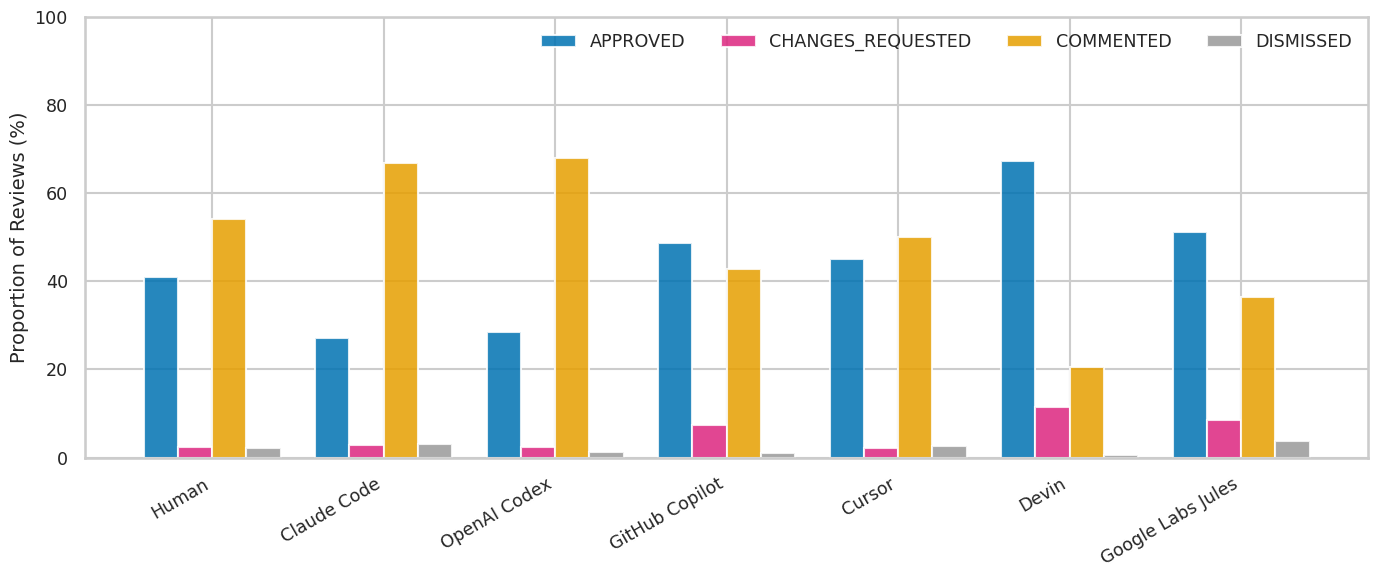

✓ Saved: figures\review_state_distribution.pdf


In [7]:
# %% Cell 6 - Review State Distribution Plot
# ---------------------------------------------------------------------------
# Grouped bar chart: review state proportions by agent (global view)
# ---------------------------------------------------------------------------

def plot_state_distribution(state_df: pd.DataFrame, out_fp: Path) -> None:
    """Plot review state distribution as grouped bars."""
    if state_df.empty:
        print("❗ No data to plot")
        return

    states = ["APPROVED (%)", "CHANGES_REQUESTED (%)", "COMMENTED (%)", "DISMISSED (%)"]
    state_colors = ["#0072B2", "#DC267F", "#E69F00", "#999999"]

    agents = state_df["Agent"].tolist()
    x = np.arange(len(agents))
    width = 0.2

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, (state, color) in enumerate(zip(states, state_colors)):
        vals = state_df[state].values
        offset = (i - 1.5) * width
        ax.bar(
            x + offset,
            vals,
            width,
            label=state.replace(" (%)", ""),
            color=color,
            alpha=0.85,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(agents, rotation=30, ha="right")
    ax.set_ylabel("Proportion of Reviews (%)")
    ax.legend(frameon=False, ncol=4, loc="upper right")
    ax.set_ylim(0, 100)

    fig.tight_layout()

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fp.with_suffix(".pdf"), dpi=300)
    fig.savefig(out_fp.with_suffix(".png"), dpi=300)
    plt.show()
    plt.close(fig)
    print(f"✓ Saved: {out_fp.with_suffix('.pdf').relative_to(out_fp.parents[1])}")


if not state_dist_global.empty:
    plot_state_distribution(state_dist_global, FIG_DIR / "review_state_distribution")

In [8]:
# %% Cell 7 - Review Body Length Comparison (Repo-Overlap Filtered)
# ---------------------------------------------------------------------------
# Compare mean review body length per PR across agents vs. repo-matched human
# ---------------------------------------------------------------------------

print("\n" + "=" * 60)
print("MEAN REVIEW BODY LENGTH PER PR (repo-overlap filtered)")
print("=" * 60)

body_length_table = compare_metric_by_agent(
    ai_pr_summary,
    human_pr_summary,
    agent_repo_sets,
    "mean_body_length",
    "Mean Body Length",
)
if not body_length_table.empty:
    print("\n" + body_length_table.to_string(index=False))


MEAN REVIEW BODY LENGTH PER PR (repo-overlap filtered)

--- Claude Code vs. Human-in-same-repos (Mean Body Length) ---
    Agent PRs: 1017, Human PRs (overlap): 3332
Cliff's delta: negligible, d=0.09160360309315467
Mann-Whitney-U-test: u=1849528.0 p=4.010025215304895e-07

--- OpenAI Codex vs. Human-in-same-repos (Mean Body Length) ---
    Agent PRs: 1457, Human PRs (overlap): 3166
Cliff's delta: negligible, d=-0.022700007067196028
Mann-Whitney-U-test: u=2254075.0 p=0.13763945888691784

--- GitHub Copilot vs. Human-in-same-repos (Mean Body Length) ---
    Agent PRs: 14779, Human PRs (overlap): 4028
Cliff's delta: negligible, d=-0.0612938102341059
Mann-Whitney-U-test: u=27940501.5 p=8.616305810862371e-15

--- Cursor vs. Human-in-same-repos (Mean Body Length) ---
    Agent PRs: 717, Human PRs (overlap): 1324
Cliff's delta: negligible, d=0.032125506158169954
Mann-Whitney-U-test: u=489902.5 p=0.15298993217025086

--- Devin vs. Human-in-same-repos (Mean Body Length) ---
    Agent PRs: 1606,

In [9]:
# %% Cell 8 - Empty-Body Approval Rate (Global)
# ---------------------------------------------------------------------------
# What proportion of APPROVED reviews have empty bodies?
# Higher empty-approval rate could indicate rubber-stamping.
# NOTE: Global rates (not repo-filtered). Repo-filtered comparisons are in
# the summary table (Cell 12) and heatmap (Cell 13).
# ---------------------------------------------------------------------------

def compute_empty_approval_rate(reviews_df: pd.DataFrame) -> pd.DataFrame:
    """Compute empty-body approval rate per agent."""
    if reviews_df.empty:
        return pd.DataFrame()

    reviews_df = reviews_df.copy()
    reviews_df["body_len"] = reviews_df["body"].fillna("").str.strip().str.len()

    rows = []
    for agent in sorted(reviews_df["agent"].unique()):
        if agent in SKIP_AGENTS:
            continue
        agent_reviews = reviews_df[reviews_df["agent"] == agent]
        approvals = agent_reviews[agent_reviews["state"] == "APPROVED"]
        total_approvals = len(approvals)
        empty_approvals = (approvals["body_len"] == 0).sum()

        rows.append(
            {
                "Agent": normalize_agent_name(agent),
                "Total Approvals": total_approvals,
                "Empty-Body Approvals": empty_approvals,
                "Empty Approval Rate (%)": (
                    round(100 * empty_approvals / total_approvals, 1)
                    if total_approvals > 0
                    else 0
                ),
            }
        )

    return pd.DataFrame(rows)


print("\n" + "=" * 60)
print("EMPTY-BODY APPROVAL RATE")
print("=" * 60)

empty_approval_df = compute_empty_approval_rate(all_reviews)
if not empty_approval_df.empty:
    print(empty_approval_df.to_string(index=False))


EMPTY-BODY APPROVAL RATE
            Agent  Total Approvals  Empty-Body Approvals  Empty Approval Rate (%)
            Human             5921                  4572                     77.2
      Claude Code             1092                   729                     66.8
     OpenAI Codex             1207                   903                     74.8
   GitHub Copilot            18890                 16597                     87.9
           Cursor              717                   498                     69.5
            Devin             1738                  1593                     91.7
Google Labs Jules              174                   132                     75.9


In [10]:
# %% Cell 9 - Author Association Distribution (Global)
# ---------------------------------------------------------------------------
# Who is reviewing? OWNER, MEMBER, COLLABORATOR, CONTRIBUTOR, etc.
# NOTE: Global rates (not repo-filtered). Provides descriptive context on
# reviewer roles across agents.
# ---------------------------------------------------------------------------

def compute_association_distribution(reviews_df: pd.DataFrame) -> pd.DataFrame:
    """Compute reviewer author_association proportions per agent."""
    if reviews_df.empty:
        return pd.DataFrame()

    associations = ["OWNER", "MEMBER", "COLLABORATOR", "CONTRIBUTOR", "NONE"]

    rows = []
    for agent in sorted(reviews_df["agent"].unique()):
        if agent in SKIP_AGENTS:
            continue
        agent_reviews = reviews_df[reviews_df["agent"] == agent]
        total = len(agent_reviews)

        row = {"Agent": normalize_agent_name(agent), "Total": total}
        for assoc in associations:
            count = (agent_reviews["author_association"] == assoc).sum()
            row[f"{assoc} (%)"] = round(100 * count / total, 1) if total > 0 else 0

        rows.append(row)

    return pd.DataFrame(rows)


print("\n" + "=" * 60)
print("REVIEWER AUTHOR ASSOCIATION")
print("=" * 60)

assoc_df = compute_association_distribution(all_reviews)
if not assoc_df.empty:
    print(assoc_df.to_string(index=False))


REVIEWER AUTHOR ASSOCIATION
            Agent  Total  OWNER (%)  MEMBER (%)  COLLABORATOR (%)  CONTRIBUTOR (%)  NONE (%)
            Human  14399        0.7        34.4              12.7             50.9       1.3
      Claude Code   4028        3.9        24.3              13.0             56.0       2.8
     OpenAI Codex   4224        4.0        24.1              29.0             39.4       3.5
   GitHub Copilot  38758        6.5        51.0              11.7             30.3       0.6
           Cursor   1593        2.4        33.6              10.5             52.1       1.4
            Devin   2582        0.0        44.2              14.3             41.1       0.3
Google Labs Jules    340       21.5        20.9              40.9             15.9       0.9


In [11]:
# %% Cell 10 - Unique Reviewers Per PR (Repo-Overlap Filtered)
# ---------------------------------------------------------------------------
# Compare unique reviewer count per PR: each agent vs. repo-matched human
# ---------------------------------------------------------------------------

print("\n" + "=" * 60)
print("UNIQUE REVIEWERS PER PR (repo-overlap filtered)")
print("=" * 60)

reviewer_count_table = compare_metric_by_agent(
    ai_pr_summary,
    human_pr_summary,
    agent_repo_sets,
    "unique_reviewers",
    "Unique Reviewers per PR",
)
if not reviewer_count_table.empty:
    print("\n" + reviewer_count_table.to_string(index=False))


UNIQUE REVIEWERS PER PR (repo-overlap filtered)

--- Claude Code vs. Human-in-same-repos (Unique Reviewers per PR) ---
    Agent PRs: 1017, Human PRs (overlap): 3332
Cliff's delta: negligible, d=0.023221973155043728
Mann-Whitney-U-test: u=1733667.5 p=0.20132149812646172

--- OpenAI Codex vs. Human-in-same-repos (Unique Reviewers per PR) ---
    Agent PRs: 1457, Human PRs (overlap): 3166
Cliff's delta: small, d=-0.16139546338043498
Mann-Whitney-U-test: u=1934183.5 p=1.8806335577014706e-25

--- GitHub Copilot vs. Human-in-same-repos (Unique Reviewers per PR) ---
    Agent PRs: 14779, Human PRs (overlap): 4028
Cliff's delta: negligible, d=-0.11629164896405182
Mann-Whitney-U-test: u=26303496.0 p=3.398871788491839e-42

--- Cursor vs. Human-in-same-repos (Unique Reviewers per PR) ---
    Agent PRs: 717, Human PRs (overlap): 1324
Cliff's delta: negligible, d=-0.08043859316470524
Mann-Whitney-U-test: u=436473.5 p=0.0004699400002609025

--- Devin vs. Human-in-same-repos (Unique Reviewers per P

C:\Users\jaker\AppData\Local\Temp\ipykernel_63864\2975856075.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jaker\AppData\Local\Temp\ipykernel_63864\2975856075.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


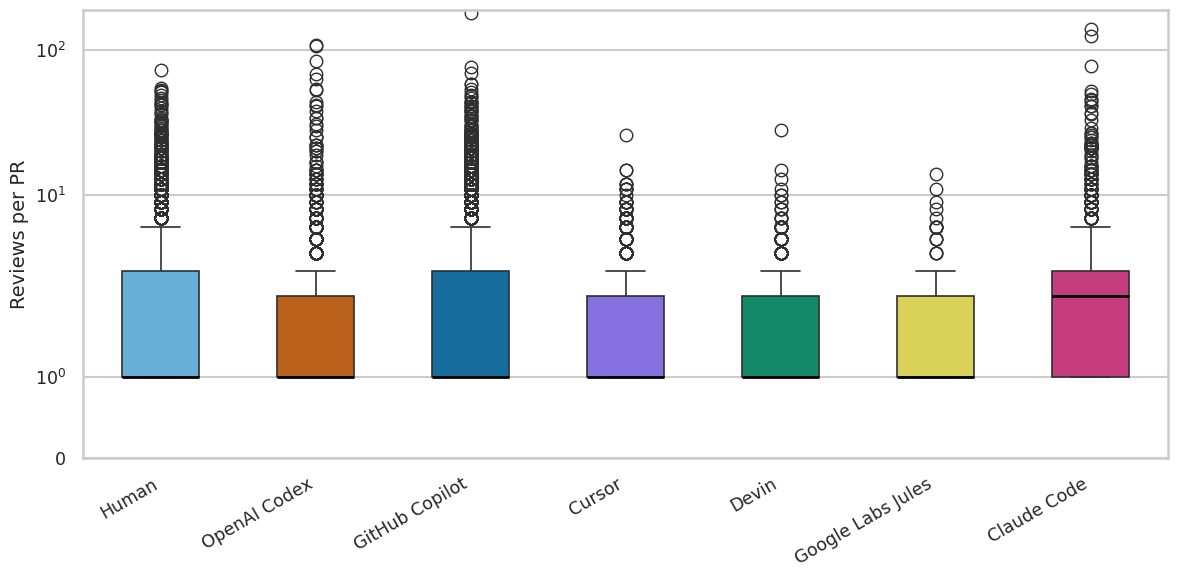

✓ Saved: figures\review_count_per_pr.pdf


In [12]:
# %% Cell 11 - Review Depth Box Plot
# ---------------------------------------------------------------------------
# Box plots: review count per PR by agent (including human baseline)
# ---------------------------------------------------------------------------

def plot_review_count_box(
    ai_summary: pd.DataFrame,
    human_summary: pd.DataFrame,
    out_fp: Path,
) -> None:
    """Plot review count per PR as box plots.

    NOTE: Uses global human baseline (not repo-filtered) as a single reference
    distribution. Per-agent repo-filtered comparisons are in the statistical
    tables. This avoids visual noise from multiple human boxes.
    """
    if ai_summary.empty or human_summary.empty:
        print("❗ Missing data for plot")
        return

    combined = pd.concat(
        [
            human_summary[["review_count", "agent"]],
            ai_summary[["review_count", "agent"]],
        ],
        ignore_index=True,
    )

    # Order: Human first, then agents sorted by median
    agent_medians = (
        combined[combined["agent"] != "Human"]
        .groupby("agent")["review_count"]
        .median()
        .sort_values()
    )
    ordered = ["Human"] + [a for a in agent_medians.index if a not in SKIP_AGENTS]

    palette = {a: get_agent_color(a) for a in ordered}

    fig, ax = plt.subplots(figsize=(12, 6))

    sns.boxplot(
        data=combined[combined["agent"].isin(ordered)],
        x="agent",
        y="review_count",
        order=ordered,
        palette=palette,
        showfliers=True,
        width=0.5,
        linewidth=1.2,
        ax=ax,
        medianprops={"linewidth": 2, "color": "#000000"},
    )

    ax.set_xlabel("")
    ax.set_ylabel("Reviews per PR")
    ax.set_yscale("symlog")
    ax.set_ylim(0)

    ax.set_xticklabels(
        [normalize_agent_name(lbl.get_text()) for lbl in ax.get_xticklabels()],
        rotation=30,
        ha="right",
    )

    fig.tight_layout()

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fp.with_suffix(".pdf"), dpi=300)
    fig.savefig(out_fp.with_suffix(".png"), dpi=300)
    plt.show()
    plt.close(fig)
    print(f"✓ Saved: {out_fp.with_suffix('.pdf').relative_to(out_fp.parents[1])}")


plot_review_count_box(ai_pr_summary, human_pr_summary, FIG_DIR / "review_count_per_pr")

In [13]:
# %% Cell 12 - Combined Comparison Table - Repo-Overlap Filtered
# ---------------------------------------------------------------------------
# One summary table for the paper: per-agent review metrics vs. repo-matched human
# ---------------------------------------------------------------------------

def build_rq2_summary_table(
    ai_summary: pd.DataFrame,
    human_summary: pd.DataFrame,
    ai_reviews: pd.DataFrame,
    human_reviews: pd.DataFrame,
    agent_repo_sets: dict,
    human_pr_repo_map: dict,
) -> pd.DataFrame:
    """Build a combined comparison table with repo-overlap-filtered human baselines."""
    rows = {}

    for agent in sorted(ai_summary["agent"].unique()):
        if agent in SKIP_AGENTS:
            continue

        a_summary = ai_summary[ai_summary["agent"] == agent]
        a_reviews = ai_reviews[ai_reviews["agent"] == agent]
        a_approvals = a_reviews[a_reviews["state"] == "APPROVED"]
        a_empty = a_approvals["body"].fillna("").str.strip().str.len() == 0

        # Repo-matched human baseline
        h_summary = get_human_baseline_for_agent(agent, human_summary, agent_repo_sets)

        if agent in agent_repo_sets:
            agent_repos = agent_repo_sets[agent]
            human_pr_ids_in_repos = {
                pr_id
                for pr_id, repo in human_pr_repo_map.items()
                if repo in agent_repos
            }
            h_reviews = human_reviews[
                human_reviews["pr_id"].isin(human_pr_ids_in_repos)
            ]
        else:
            h_reviews = human_reviews

        h_approvals = h_reviews[h_reviews["state"] == "APPROVED"]
        h_empty = h_approvals["body"].fillna("").str.strip().str.len() == 0

        name = normalize_agent_name(agent)

        # Agent row
        rows[name] = {
            "N PRs": len(a_summary),
            "Med Reviews/PR": a_summary["review_count"].median(),
            "Med Reviewers/PR": a_summary["unique_reviewers"].median(),
            "APPROVED (%)": (
                round(100 * (a_reviews["state"] == "APPROVED").mean(), 1)
                if len(a_reviews) > 0
                else 0
            ),
            "CHG_REQ (%)": (
                round(100 * (a_reviews["state"] == "CHANGES_REQUESTED").mean(), 1)
                if len(a_reviews) > 0
                else 0
            ),
            "COMMENTED (%)": (
                round(100 * (a_reviews["state"] == "COMMENTED").mean(), 1)
                if len(a_reviews) > 0
                else 0
            ),
            "Empty Appr (%)": (
                round(100 * a_empty.mean(), 1) if len(a_approvals) > 0 else 0
            ),
            "Med Body Len": round(a_summary["mean_body_length"].median(), 0),
        }

        # Matched human row
        rows[f"Human (vs {name})"] = {
            "N PRs": len(h_summary),
            "Med Reviews/PR": (
                h_summary["review_count"].median() if len(h_summary) > 0 else 0
            ),
            "Med Reviewers/PR": (
                h_summary["unique_reviewers"].median() if len(h_summary) > 0 else 0
            ),
            "APPROVED (%)": (
                round(100 * (h_reviews["state"] == "APPROVED").mean(), 1)
                if len(h_reviews) > 0
                else 0
            ),
            "CHG_REQ (%)": (
                round(100 * (h_reviews["state"] == "CHANGES_REQUESTED").mean(), 1)
                if len(h_reviews) > 0
                else 0
            ),
            "COMMENTED (%)": (
                round(100 * (h_reviews["state"] == "COMMENTED").mean(), 1)
                if len(h_reviews) > 0
                else 0
            ),
            "Empty Appr (%)": (
                round(100 * h_empty.mean(), 1) if len(h_approvals) > 0 else 0
            ),
            "Med Body Len": (
                round(h_summary["mean_body_length"].median(), 0)
                if len(h_summary) > 0
                else 0
            ),
        }

    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index.name = "Agent"
    return df


print("\n" + "=" * 60)
print("RQ2 SUMMARY TABLE (repo-overlap filtered)")
print("=" * 60)

summary_table = build_rq2_summary_table(
    ai_pr_summary,
    human_pr_summary,
    ai_reviews,
    human_reviews,
    agent_repo_sets,
    human_pr_repo_map,
)
print(summary_table)

# Save
table_csv = FIG_DIR / "rq2_review_comparison.csv"
table_tex = FIG_DIR / "rq2_review_comparison.tex"

summary_table.to_csv(table_csv)

latex = summary_table.to_latex(
    escape=False,
    float_format="%.1f",
    caption="Review depth metrics by agent vs. repo-matched human baseline",
    label="tab:rq2_review_comparison",
)
table_tex.write_text(latex)

print(f"\n✓ Saved: {table_csv.relative_to(FIG_DIR.parent)}")
print(f"✓ Saved: {table_tex.relative_to(FIG_DIR.parent)}")


RQ2 SUMMARY TABLE (repo-overlap filtered)
                              N PRs  Med Reviews/PR  Med Reviewers/PR  \
Agent                                                                   
Claude Code                    1017             2.0               1.0   
Human (vs Claude Code)         3332             1.0               1.0   
OpenAI Codex                   1457             1.0               1.0   
Human (vs OpenAI Codex)        3166             1.0               1.0   
GitHub Copilot                14779             1.0               1.0   
Human (vs GitHub Copilot)      4028             1.0               1.0   
Cursor                          717             1.0               1.0   
Human (vs Cursor)              1324             1.0               1.0   
Devin                          1606             1.0               1.0   
Human (vs Devin)                411             1.0               1.0   
Google Labs Jules               185             1.0               1.0   
Human (v

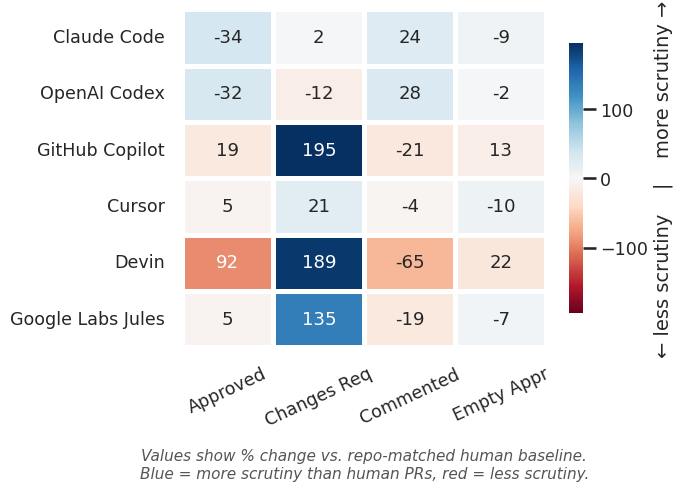

✓ Saved: figures\rq2_trust_heatmap.pdf
✓ Saved: figures\rq2_trust_heatmap.png

HEATMAP VALUES (% change vs repo-matched human baseline)

  Claude Code:
    Reviews/PR          : agent=2.0, human=1.0, delta=+100%
    Reviewers/PR        : agent=1.0, human=1.0, delta=+0%
    Body Length         : agent=0.0, human=0.0, delta=+0%
    Approved %          : agent=27.1%, human=41.2%, delta=-34%
    Changes Req %       : agent=2.9%, human=2.8%, delta=+2%
    Commented %         : agent=66.9%, human=53.8%, delta=+24%
    Empty Appr %        : agent=66.8%, human=73.3%, delta=-9%

  OpenAI Codex:
    Reviews/PR          : agent=1.0, human=1.0, delta=+0%
    Reviewers/PR        : agent=1.0, human=1.0, delta=+0%
    Body Length         : agent=0.0, human=0.0, delta=+0%
    Approved %          : agent=28.6%, human=42.0%, delta=-32%
    Changes Req %       : agent=2.3%, human=2.6%, delta=-12%
    Commented %         : agent=67.9%, human=53.1%, delta=+28%
    Empty Appr %        : agent=74.8%, human=7

In [14]:
# %% Cell 13 - Delta Heatmap
# Single figure for the paper: heatmap showing how each agent's review
# metrics deviate from the repo-matched human baseline.
# Blue = more scrutiny than human PRs receive, red = less scrutiny.
# Annotations show ORIGINAL (unflipped) % change values for readability.
# ---------------------------------------------------------------------------

def plot_trust_heatmap(
    ai_summary: pd.DataFrame,
    human_summary: pd.DataFrame,
    agent_repo_sets: dict,
    out_fp: Path,
    *,
    font_size: int = 14,
) -> None:
    """
    Heatmap of (agent - repo-matched human baseline) across review metrics.
    Color: blue = more scrutiny, red = less scrutiny.
    Annotations: original % change (not sign-flipped).

    Focuses on review-state metrics where meaningful variation exists.
    PR-level medians (reviews/PR, reviewers/PR, body length) are excluded
    because medians are identical across agents - distributional differences
    are captured by the Mann-Whitney tests in earlier cells.
    """
    agents = sorted([a for a in ai_summary["agent"].unique() if a not in SKIP_AGENTS])

    # Build delta matrices: one for annotations (original), one for colors (flipped)
    annot_data = []
    color_data = []
    all_labels = []

    for agent in agents:
        a_summary = ai_summary[ai_summary["agent"] == agent]
        h_summary = get_human_baseline_for_agent(agent, human_summary, agent_repo_sets)

        if h_summary.empty:
            continue

        annot_row = {}
        color_row = {}

        # Review-state metrics (computed from review-level data)
        a_revs = ai_reviews[ai_reviews["agent"] == agent]

        if agent in agent_repo_sets:
            h_pr_ids = {
                pr_id
                for pr_id, repo in human_pr_repo_map.items()
                if repo in agent_repo_sets[agent]
            }
            h_revs = human_reviews[human_reviews["pr_id"].isin(h_pr_ids)]
        else:
            h_revs = human_reviews

        if len(a_revs) > 0 and len(h_revs) > 0:
            # flip=True means higher values indicate LESS scrutiny
            for state, label, flip in [
                ("APPROVED", "Approved", True),
                ("CHANGES_REQUESTED", "Changes Req", False),
                ("COMMENTED", "Commented", False),
            ]:
                a_rate = 100 * (a_revs["state"] == state).mean()
                h_rate = 100 * (h_revs["state"] == state).mean()
                if h_rate != 0:
                    pct_change = ((a_rate - h_rate) / abs(h_rate)) * 100
                else:
                    pct_change = 0
                annot_row[label] = pct_change
                color_row[label] = -pct_change if flip else pct_change

            # Empty approval rate
            a_appr = a_revs[a_revs["state"] == "APPROVED"]
            h_appr = h_revs[h_revs["state"] == "APPROVED"]
            a_empty = (
                (a_appr["body"].fillna("").str.strip().str.len() == 0).mean() * 100
                if len(a_appr) > 0
                else 0
            )
            h_empty = (
                (h_appr["body"].fillna("").str.strip().str.len() == 0).mean() * 100
                if len(h_appr) > 0
                else 0
            )
            if h_empty != 0:
                pct_change = ((a_empty - h_empty) / abs(h_empty)) * 100
            else:
                pct_change = 0
            annot_row["Empty Appr"] = pct_change
            color_row["Empty Appr"] = -pct_change  # flip: more empty = less scrutiny

        annot_data.append(annot_row)
        color_data.append(color_row)
        all_labels.append(normalize_agent_name(agent))

    if not annot_data:
        print("❗ No data for heatmap")
        return

    annot_df = pd.DataFrame(annot_data, index=all_labels)
    color_df = pd.DataFrame(color_data, index=all_labels)

    # Plot using color_df for colors, annot_df for labels
    fig, ax = plt.subplots(figsize=(7, 7))

    vmax = max(abs(color_df.values.min()), abs(color_df.values.max()), 50)
    vmax = min(vmax, 200)

    # Create the heatmap with color data
    sns.heatmap(
        color_df,
        annot=annot_df.values,  # Show original values
        fmt=".0f",
        center=0,
        cmap="RdBu",
        vmin=-vmax,
        vmax=vmax,
        linewidths=2.5,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": "← less scrutiny    |    more scrutiny →", "shrink": 0.8},
        annot_kws={"size": font_size - 1},
    )

    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.tick_params(axis="y", rotation=0)

    ax.text(
        0.5,
        -0.3,
        "Values show % change vs. repo-matched human baseline.\n"
        "Blue = more scrutiny than human PRs, red = less scrutiny.",
        ha="center",
        va="top",
        fontsize=font_size - 3,
        transform=ax.transAxes,
        style="italic",
        color="#555555",
    )

    fig.tight_layout(rect=[0, 0.18, 1, 1])

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fp.with_suffix(".pdf"), dpi=300, bbox_inches="tight")
    fig.savefig(out_fp.with_suffix(".png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"✓ Saved: {out_fp.with_suffix('.pdf').relative_to(out_fp.parents[1])}")
    print(f"✓ Saved: {out_fp.with_suffix('.png').relative_to(out_fp.parents[1])}")


plot_trust_heatmap(
    ai_pr_summary, human_pr_summary, agent_repo_sets, FIG_DIR / "rq2_trust_heatmap"
)

# Print heatmap values numerically for reference
print("\n" + "=" * 60)
print("HEATMAP VALUES (% change vs repo-matched human baseline)")
print("=" * 60)

for agent in sorted(
    [a for a in ai_pr_summary["agent"].unique() if a not in SKIP_AGENTS]
):
    a_summary = ai_pr_summary[ai_pr_summary["agent"] == agent]
    h_summary = get_human_baseline_for_agent(agent, human_pr_summary, agent_repo_sets)

    if h_summary.empty:
        continue

    name = normalize_agent_name(agent)
    print(f"\n  {name}:")

    # PR-level metrics
    for col, label in [
        ("review_count", "Reviews/PR"),
        ("unique_reviewers", "Reviewers/PR"),
        ("mean_body_length", "Body Length"),
    ]:
        a_med = a_summary[col].median()
        h_med = h_summary[col].median()
        pct = ((a_med - h_med) / abs(h_med)) * 100 if h_med != 0 else 0
        print(f"    {label:<20s}: agent={a_med:.1f}, human={h_med:.1f}, delta={pct:+.0f}%")

    # Review-level metrics
    a_revs = ai_reviews[ai_reviews["agent"] == agent]
    if agent in agent_repo_sets:
        h_pr_ids = {
            pr_id
            for pr_id, repo in human_pr_repo_map.items()
            if repo in agent_repo_sets[agent]
        }
        h_revs = human_reviews[human_reviews["pr_id"].isin(h_pr_ids)]
    else:
        h_revs = human_reviews

    if len(a_revs) > 0 and len(h_revs) > 0:
        for state, label in [
            ("APPROVED", "Approved %"),
            ("CHANGES_REQUESTED", "Changes Req %"),
            ("COMMENTED", "Commented %"),
        ]:
            a_rate = 100 * (a_revs["state"] == state).mean()
            h_rate = 100 * (h_revs["state"] == state).mean()
            pct = ((a_rate - h_rate) / abs(h_rate)) * 100 if h_rate != 0 else 0
            print(f"    {label:<20s}: agent={a_rate:.1f}%, human={h_rate:.1f}%, delta={pct:+.0f}%")

        a_appr = a_revs[a_revs["state"] == "APPROVED"]
        h_appr = h_revs[h_revs["state"] == "APPROVED"]
        a_empty = (
            (a_appr["body"].fillna("").str.strip().str.len() == 0).mean() * 100
            if len(a_appr) > 0
            else 0
        )
        h_empty = (
            (h_appr["body"].fillna("").str.strip().str.len() == 0).mean() * 100
            if len(h_appr) > 0
            else 0
        )
        pct = ((a_empty - h_empty) / abs(h_empty)) * 100 if h_empty != 0 else 0
        print(f"    {'Empty Appr %':<20s}: agent={a_empty:.1f}%, human={h_empty:.1f}%, delta={pct:+.0f}%")

In [17]:
# %% Cell 14 - Summary
print("\n" + "=" * 60)
print("RQ2 ANALYSIS COMPLETE")
print("=" * 60)
print(f"Figures saved to: {FIG_DIR.relative_to(FIG_DIR.parent.parent) if FIG_DIR.parent.parent.exists() else FIG_DIR.name}")
print("\nGenerated files:")
print(f"  - review_state_distribution.pdf/png")
print(f"  - review_count_per_pr.pdf/png")
print(f"  - rq2_trust_heatmap.pdf/png")
print(f"  - rq2_review_comparison.csv")
print(f"  - rq2_review_comparison.tex")
print("=" * 60)


RQ2 ANALYSIS COMPLETE
Figures saved to: aidev-extended\figures

Generated files:
  - review_state_distribution.pdf/png
  - review_count_per_pr.pdf/png
  - rq2_trust_heatmap.pdf/png
  - rq2_review_comparison.csv
  - rq2_review_comparison.tex
